# Gershgorin condition-number estimation for two diagonally dominant SPD families

This notebook compares the Gershgorin estimate with the exact spectral condition number

$$
\kappa_2(A)
=
\frac{\lambda_{\max}(A)}
{\lambda_{\min}(A)}
$$

for:

1. Random strictly diagonally dominant SPD matrices.
2. Deterministic diagonally dominant SPD tridiagonal matrices.

A prediction is counted as accurate when

$$
\frac{
|\kappa_{\mathrm{Gershgorin}}-\kappa_2|
}{
|\kappa_2|
}
< 0.3.
$$

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import eigvalsh

np.set_printoptions(precision=5, suppress=True)

## Gershgorin estimator and exact reference

In [13]:
def exact_cond_2_spd(A):
    """
    Exact spectral condition number for an SPD matrix.
    Used only as the benchmark.
    """
    eigenvalues = eigvalsh(A)
    return eigenvalues[-1] / eigenvalues[0]


def gershgorin_cond_2_estimate(A):
    """
    Gershgorin estimate of kappa_2 for a symmetric matrix.

    For row i,

    radius_i = sum_{j != i} |a_ij|.

    Then

    lambda_min >= min_i(a_ii - radius_i),
    lambda_max <= max_i(a_ii + radius_i).

    Returns np.inf when the lower bound is nonpositive.
    """
    A = np.asarray(A, dtype=float)

    diagonal = np.diag(A)
    radii = np.sum(np.abs(A), axis=1) - np.abs(diagonal)

    lambda_lower = np.min(diagonal - radii)
    lambda_upper = np.max(diagonal + radii)

    if lambda_lower <= 0:
        return np.inf, lambda_lower, lambda_upper

    kappa_estimate = lambda_upper / lambda_lower

    return kappa_estimate, lambda_lower, lambda_upper


def relative_error(predicted, true):
    if not np.isfinite(predicted):
        return np.inf

    return abs(predicted - true) / abs(true)

## Matrix generators

### Random diagonally dominant SPD matrices

A symmetric random off-diagonal matrix is generated first. The diagonal is then set to

$$
a_{ii}
=
\sum_{j\neq i}|a_{ij}|
+
\delta_i,
$$

where

$$
\delta_i>0.
$$

This guarantees strict diagonal dominance and positive definiteness.

### Deterministic diagonally dominant SPD matrices

We use a tridiagonal Toeplitz matrix

$$
A=
\begin{pmatrix}
d & -c & 0 & \cdots & 0\\
-c & d & -c & \ddots & \vdots\\
0 & -c & d & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & -c\\
0 & \cdots & 0 & -c & d
\end{pmatrix},
$$

with

$$
d>2|c|.
$$

This is deterministic, symmetric, strictly diagonally dominant, and SPD.

In [14]:
def random_diagonally_dominant_spd(
    n,
    rng,
    density=0.25,
    margin_min=0.1,
    margin_max=2.0
):
    """
    Random symmetric strictly diagonally dominant SPD matrix.
    """
    random_entries = rng.uniform(-1.0, 1.0, size=(n, n))
    mask = rng.random((n, n)) < density

    upper = np.triu(random_entries * mask, k=1)
    off_diagonal = upper + upper.T

    row_abs_sum = np.sum(np.abs(off_diagonal), axis=1)
    margin = rng.uniform(margin_min, margin_max, size=n)

    diagonal = row_abs_sum + margin

    return off_diagonal + np.diag(diagonal)


def deterministic_diagonally_dominant_spd(
    n,
    off_diagonal_strength=1.0,
    dominance_margin=0.5
):
    """
    Deterministic tridiagonal Toeplitz SPD matrix.

    diagonal = 2*|off_diagonal_strength| + dominance_margin.
    """
    c = abs(off_diagonal_strength)
    d = 2.0 * c + dominance_margin

    A = np.diag(np.full(n, d))

    if n > 1:
        A += np.diag(np.full(n - 1, -c), k=1)
        A += np.diag(np.full(n - 1, -c), k=-1)

    return A

## Experiment configuration

In [15]:
MATRIX_SIZES = [20, 40, 80, 120]
RANDOM_SAMPLES_PER_SIZE = 30

# Several deterministic matrices at each size.
DETERMINISTIC_MARGINS = [0.1, 0.3, 0.5, 1.0, 2.0]
DETERMINISTIC_OFF_DIAGONAL_STRENGTHS = [0.5, 1.0, 2.0]

RELATIVE_ERROR_THRESHOLD = 0.30
RANDOM_SEED = 2026

## Run the experiment

In [16]:
rng = np.random.default_rng(RANDOM_SEED)
records = []

# Random diagonally dominant SPD matrices.
for n in MATRIX_SIZES:
    for sample in range(RANDOM_SAMPLES_PER_SIZE):
        A = random_diagonally_dominant_spd(
            n=n,
            rng=rng,
            density=0.25
        )

        true_kappa = exact_cond_2_spd(A)

        (
            predicted_kappa,
            lambda_lower,
            lambda_upper
        ) = gershgorin_cond_2_estimate(A)

        error = relative_error(predicted_kappa, true_kappa)

        records.append({
            "family": "random diagonally dominant SPD",
            "size": n,
            "sample": sample,
            "parameters": "random",
            "true_kappa2": true_kappa,
            "gershgorin_kappa2": predicted_kappa,
            "gershgorin_lower": lambda_lower,
            "gershgorin_upper": lambda_upper,
            "relative_error": error,
            "finite": np.isfinite(predicted_kappa),
            "accurate_within_30_percent": (
                np.isfinite(predicted_kappa)
                and error < RELATIVE_ERROR_THRESHOLD
            )
        })

# Deterministic diagonally dominant SPD matrices.
for n in MATRIX_SIZES:
    sample = 0

    for margin in DETERMINISTIC_MARGINS:
        for strength in DETERMINISTIC_OFF_DIAGONAL_STRENGTHS:
            A = deterministic_diagonally_dominant_spd(
                n=n,
                off_diagonal_strength=strength,
                dominance_margin=margin
            )

            true_kappa = exact_cond_2_spd(A)

            (
                predicted_kappa,
                lambda_lower,
                lambda_upper
            ) = gershgorin_cond_2_estimate(A)

            error = relative_error(predicted_kappa, true_kappa)

            records.append({
                "family": "deterministic diagonally dominant SPD",
                "size": n,
                "sample": sample,
                "parameters": (
                    f"strength={strength}, margin={margin}"
                ),
                "true_kappa2": true_kappa,
                "gershgorin_kappa2": predicted_kappa,
                "gershgorin_lower": lambda_lower,
                "gershgorin_upper": lambda_upper,
                "relative_error": error,
                "finite": np.isfinite(predicted_kappa),
                "accurate_within_30_percent": (
                    np.isfinite(predicted_kappa)
                    and error < RELATIVE_ERROR_THRESHOLD
                )
            })

            sample += 1

results = pd.DataFrame(records)
results.head()

,family,size,sample,parameters,true_kappa2,gershgorin_kappa2,gershgorin_lower,gershgorin_upper,relative_error,finite,accurate_within_30_percent
0,random diagonally dominant SPD,20,0,random,10.449979,86.287086,0.109615,9.458392,7.257154,True,False
1,random diagonally dominant SPD,20,1,random,6.982370,48.780555,0.211421,10.313230,5.986246,True,False
2,random diagonally dominant SPD,20,2,random,7.930415,60.823898,0.142044,8.639673,6.669699,True,False
3,random diagonally dominant SPD,20,3,random,12.728059,83.368073,0.116340,9.699066,5.549944,True,False
4,random diagonally dominant SPD,20,4,random,7.365886,28.059235,0.292140,8.197224,2.809349,True,False


## Accuracy percentage by matrix size

For each family and matrix size,

$$
\mathrm{accuracy}(n)
=
100
\frac{
N_{\mathrm{relative\ error}<0.3}
}{
N_{\mathrm{finite\ Gershgorin}}
}.
$$

In [17]:
summary_rows = []

for (family, n), group in results.groupby(["family", "size"]):
    finite_group = group[group["finite"]]

    if len(finite_group) > 0:
        accuracy = (
            100.0
            * finite_group["accurate_within_30_percent"].mean()
        )

        mean_relative_error = finite_group["relative_error"].mean()
        median_relative_error = finite_group["relative_error"].median()
    else:
        accuracy = np.nan
        mean_relative_error = np.nan
        median_relative_error = np.nan

    summary_rows.append({
        "family": family,
        "size": n,
        "total_samples": len(group),
        "finite_samples": len(finite_group),
        "finite_percent": (
            100.0 * len(finite_group) / len(group)
        ),
        "accuracy_percent_finite_only": accuracy,
        "mean_relative_error_finite_only": mean_relative_error,
        "median_relative_error_finite_only": median_relative_error
    })

accuracy_by_size = pd.DataFrame(summary_rows)
accuracy_by_size

,family,size,total_samples,finite_samples,finite_percent,accuracy_percent_finite_only,mean_relative_error_finite_only,median_relative_error_finite_only
0,deterministic diagonally dominant SPD,20,15,15,100.0,93.333333,0.092932,0.049888
1,deterministic diagonally dominant SPD,40,15,15,100.0,100.000000,0.024319,0.013058
2,deterministic diagonally dominant SPD,80,15,15,100.0,100.000000,0.006227,0.003344
3,deterministic diagonally dominant SPD,120,15,15,100.0,100.000000,0.002790,0.001498
4,random diagonally dominant SPD,20,30,30,100.0,0.000000,7.402642,6.739945
5,random diagonally dominant SPD,40,30,30,100.0,0.000000,22.630388,21.544834
6,random diagonally dominant SPD,80,30,30,100.0,0.000000,67.277153,70.210680
7,random diagonally dominant SPD,120,30,30,100.0,0.000000,124.981465,127.391822


## Main comparison figure

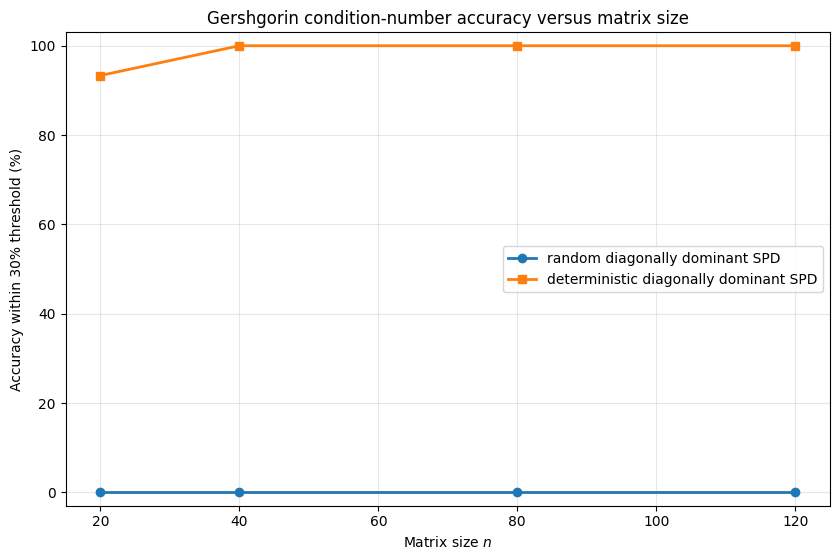

In [18]:
plt.figure(figsize=(8.5, 5.7))

for family, marker in [
    ("random diagonally dominant SPD", "o"),
    ("deterministic diagonally dominant SPD", "s")
]:
    group = accuracy_by_size[
        accuracy_by_size["family"] == family
    ]

    plt.plot(
        group["size"],
        group["accuracy_percent_finite_only"],
        marker=marker,
        linewidth=2,
        label=family
    )

plt.xlabel("Matrix size $n$")
plt.ylabel("Accuracy within 30% threshold (%)")
plt.title(
    "Gershgorin condition-number accuracy versus matrix size"
)
plt.ylim(-3, 103)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Gershgorin estimate versus exact condition number

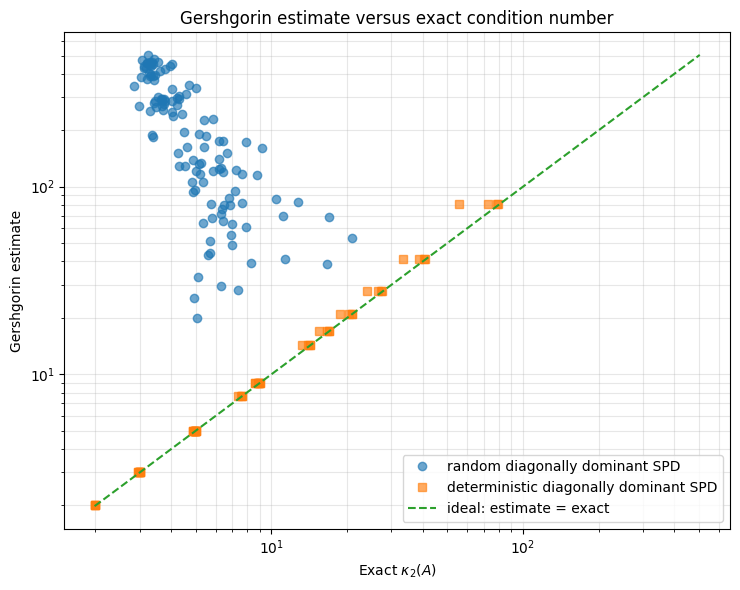

In [19]:
plt.figure(figsize=(7.5, 6))

for family, marker in [
    ("random diagonally dominant SPD", "o"),
    ("deterministic diagonally dominant SPD", "s")
]:
    group = results[
        (results["family"] == family)
        & results["finite"]
    ]

    plt.loglog(
        group["true_kappa2"],
        group["gershgorin_kappa2"],
        marker,
        linestyle="none",
        alpha=0.65,
        label=family
    )

finite_results = results[results["finite"]]

lower = min(
    finite_results["true_kappa2"].min(),
    finite_results["gershgorin_kappa2"].min()
)

upper = max(
    finite_results["true_kappa2"].max(),
    finite_results["gershgorin_kappa2"].max()
)

plt.loglog(
    [lower, upper],
    [lower, upper],
    "--",
    label="ideal: estimate = exact"
)

plt.xlabel("Exact $\\kappa_2(A)$")
plt.ylabel("Gershgorin estimate")
plt.title("Gershgorin estimate versus exact condition number")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Mean relative error by matrix size

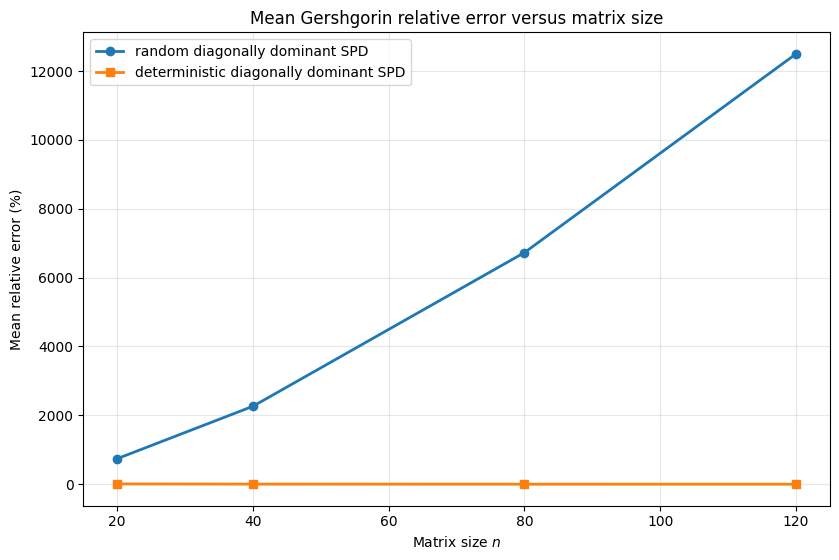

In [20]:
plt.figure(figsize=(8.5, 5.7))

for family, marker in [
    ("random diagonally dominant SPD", "o"),
    ("deterministic diagonally dominant SPD", "s")
]:
    group = accuracy_by_size[
        accuracy_by_size["family"] == family
    ]

    plt.plot(
        group["size"],
        100.0 * group["mean_relative_error_finite_only"],
        marker=marker,
        linewidth=2,
        label=family
    )

plt.xlabel("Matrix size $n$")
plt.ylabel("Mean relative error (%)")
plt.title(
    "Mean Gershgorin relative error versus matrix size"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Detailed numerical results

In [21]:
display_columns = [
    "family",
    "size",
    "sample",
    "parameters",
    "true_kappa2",
    "gershgorin_kappa2",
    "gershgorin_lower",
    "gershgorin_upper",
    "relative_error",
    "accurate_within_30_percent"
]

results[display_columns]

,family,size,sample,parameters,true_kappa2,gershgorin_kappa2,gershgorin_lower,gershgorin_upper,relative_error,accurate_within_30_percent
0,random diagonally dominant SPD,20,0,random,10.449979,86.287086,0.109615,9.458392,7.257154,False
1,random diagonally dominant SPD,20,1,random,6.982370,48.780555,0.211421,10.313230,5.986246,False
2,random diagonally dominant SPD,20,2,random,7.930415,60.823898,0.142044,8.639673,6.669699,False
3,random diagonally dominant SPD,20,3,random,12.728059,83.368073,0.116340,9.699066,5.549944,False
4,random diagonally dominant SPD,20,4,random,7.365886,28.059235,0.292140,8.197224,2.809349,False
...,...,...,...,...,...,...,...,...,...,...
175,deterministic diagonally dominant SPD,120,10,"strength=1.0, margin=1.0",4.995958,5.000000,1.000000,5.000000,0.000809,True
176,deterministic diagonally dominant SPD,120,11,"strength=2.0, margin=1.0",8.986537,9.000000,1.000000,9.000000,0.001498,True
177,deterministic diagonally dominant SPD,120,12,"strength=0.5, margin=2.0",1.999495,2.000000,2.000000,4.000000,0.000253,True
178,deterministic diagonally dominant SPD,120,13,"strength=1.0, margin=2.0",2.998652,3.000000,2.000000,6.000000,0.000449,True
